In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv('/content/dataset.csv')

In [ ]:
data.shape

(144233, 434)

Time based split is executed . the reason for the split is to prevent data leakage

In [ ]:
data = data.sort_values('TransactionDT')

In [ ]:
split_index = int(len(data) * 0.8)

df = data.iloc[:split_index].copy()
test_df = data.iloc[split_index:].copy()

**Amount-Based Rules**

In [ ]:
df['TransactionAmt'].max()

1800.0

In [ ]:
df['TransactionAmt'].min()

0.251

In [ ]:
df['TransactionAmt'].mean()

np.float64(85.69040785710574)

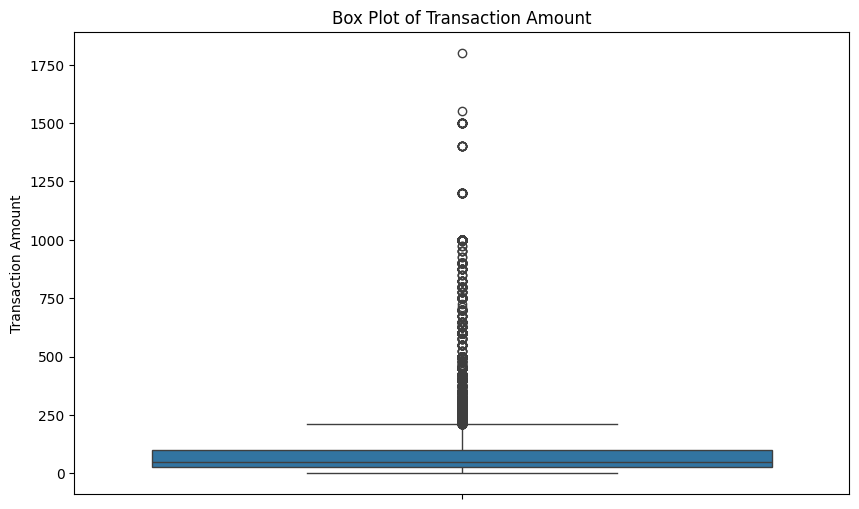

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['TransactionAmt'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Transaction Amount')
plt.show()

**amount>200** ---> rule_high_amount<br>
**amount>500** --->rule_very_high_amount

In [ ]:
#training
df['rule_high_amount'] = (df['TransactionAmt'] > 200).astype(int)
df['rule_very_high_amount'] = (df['TransactionAmt'] > 500).astype(int)

In [ ]:
#testing
test_df['rule_high_amount'] = (test_df['TransactionAmt'] > 200).astype(int)
test_df['rule_very_high_amount']= (test_df['TransactionAmt'] > 500).astype(int)

**Time-Based Rules**

given **transactionDT in seconds w.r.t some time** so converting seconds to hour ,to categorize whether it is night transaction or not

In [ ]:
#training
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['rule_night_txn'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)

In [ ]:
#testing
test_df['hour'] = (test_df['TransactionDT'] // 3600) % 24
test_df['rule_night_txn'] = ((test_df['hour'] >= 0) & (test_df['hour'] <= 5)).astype(int)

**Device Risk Rules**


insight of the device type fraud rate in training data

In [ ]:
device_fraud = df.groupby('DeviceType')['isFraud'].agg(['count', 'sum'])

device_fraud['fraud_rate'] = device_fraud['sum'] / device_fraud['count']

print(device_fraud.sort_values(by='fraud_rate', ascending=False))

            count   sum  fraud_rate
DeviceType                         
mobile      43870  4354    0.099248
desktop     68854  4229    0.061420


based upon the training data mobile has more fraud rate so putting up the flag that it is mobile.<br>
if device type is null then we are putting up the flag that it is suspicious

In [ ]:
#training

df['rule_mobile'] = (df['DeviceType'] == 'mobile').astype(int)
# suspicious device flag
df['rule_suspicious_device'] = df['DeviceInfo'].isna().astype(int)

In [ ]:
#testing
test_df['rule_mobile'] = (test_df['DeviceType'] == 'mobile').astype(int)
test_df['rule_suspicious_device'] = test_df['DeviceInfo'].isna().astype(int)

**Email Domain Rules**

training data


In [ ]:
df['R_emaildomain'].value_counts()


,count
R_emaildomain,
gmail.com,43339
hotmail.com,19680
anonymous.com,15941
yahoo.com,8411
aol.com,3139
outlook.com,1799
comcast.net,1540
icloud.com,1073
yahoo.com.mx,908


putting up a flag for email missing column on training data


In [ ]:
df['rule_missing_email'] = df['R_emaildomain'].isna().astype(int)

avg fraud rate of r_email_domain

In [ ]:
email_fraud = df.groupby('R_emaildomain')['isFraud'].mean().sort_values(ascending=False)

print(email_fraud.head(20))

R_emaildomain
protonmail.com    0.950000
mail.com          0.361111
outlook.com       0.160089
outlook.es        0.138462
icloud.com        0.120224
gmail.com         0.115231
earthlink.net     0.090909
hotmail.com       0.079827
hotmail.es        0.066327
yahoo.fr          0.059524
yahoo.com         0.055879
live.com          0.049759
charter.net       0.046729
ymail.com         0.046243
aol.com           0.036954
aim.com           0.035714
anonymous.com     0.027915
yahoo.es          0.023256
live.com.mx       0.022088
cox.net           0.015345
Name: isFraud, dtype: float64


mean alone is not sufficient. because the count of particular email may be more but mean might not be top so we considered ***both mean and count***

In [ ]:
email_stats = df.groupby('R_emaildomain')['isFraud'].agg(['count', 'mean'])


email_stats = email_stats.sort_values(by='mean', ascending=False)

# Filter only reliable domains
email_stats_filtered = email_stats[email_stats['count'] > 100]

print(email_stats_filtered.head(20))

                count      mean
R_emaildomain                  
mail.com          108  0.361111
outlook.com      1799  0.160089
outlook.es        325  0.138462
icloud.com       1073  0.120224
gmail.com       43339  0.115231
hotmail.com     19680  0.079827
hotmail.es        196  0.066327
yahoo.com        8411  0.055879
live.com          623  0.049759
charter.net       107  0.046729
ymail.com         173  0.046243
aol.com          3139  0.036954
anonymous.com   15941  0.027915
live.com.mx       498  0.022088
cox.net           391  0.015345
comcast.net      1540  0.013636
optonline.net     157  0.012739
yahoo.com.mx      908  0.008811
prodigy.net.mx    133  0.007519
me.com            445  0.002247


 “For each email domain:

how many transactions? (count)

how many are fraud (in %)? (mean)”

***high risk if mean>30 <br>
medium riskk if mean>15***

In [ ]:
high_risk_domains = email_stats[
    (email_stats['mean'] > 0.3) & (email_stats['count'] > 50)
].index

In [ ]:
medium_risk_domains = email_stats[
    (email_stats['mean'] > 0.15) & (email_stats['count'] > 100)
].index

In [ ]:
df['rule_email_high'] = df['R_emaildomain'].isin(high_risk_domains).astype(int)

df['rule_email_medium'] = df['R_emaildomain'].isin(medium_risk_domains).astype(int)

In [ ]:
df['rule_email_score'] = (
    df['rule_email_high'] * 30 +
    df['rule_email_medium'] * 15
)

In [ ]:
df['email_fraud_rate'] = df['R_emaildomain'].map(email_stats['mean'])

testing data

In [ ]:
test_df['rule_missing_email'] = df['R_emaildomain'].isna().astype(int)

In [ ]:
high_risk_domains_test = email_stats[
    (email_stats['mean'] > 0.3) & (email_stats['count'] > 50)
].index

In [ ]:
medium_risk_domains_test = email_stats[
    (email_stats['mean'] > 0.15) & (email_stats['count'] > 100)
].index

In [ ]:
test_df['rule_email_high'] = test_df['R_emaildomain'].isin(high_risk_domains_test).astype(int)

test_df['rule_email_medium'] = test_df['R_emaildomain'].isin(medium_risk_domains_test).astype(int)

In [ ]:
test_df['rule_email_score'] = (
    test_df['rule_email_high'] * 30 +
    test_df['rule_email_medium'] * 15
)

In [ ]:
test_df['email_fraud_rate'] = test_df['R_emaildomain'].map(email_stats['mean'])

**Velocity Rule**

transaction count in last 1hr  <br>
id >5 then it is rule_high_velocity

In [ ]:
# =========================
# 1. SORT (VERY IMPORTANT)
# =========================
df = df.sort_values(['card1', 'TransactionDT'])
test_df = test_df.sort_values(['card1', 'TransactionDT'])


# =========================
# 2. CARD AVG (TRAIN ONLY)
# =========================
card_avg_map = df.groupby('card1')['TransactionAmt'].mean()

df['card_avg_amt'] = df['card1'].map(card_avg_map)
df['amt_ratio'] = df['TransactionAmt'] / df['card_avg_amt']


# =========================
# 3. APPLY TO TEST (NO LEAKAGE)
# =========================
test_df['card_avg_amt'] = test_df['card1'].map(card_avg_map)

# handle unseen cards
global_mean = df['TransactionAmt'].mean()
test_df['card_avg_amt'] = test_df['card_avg_amt'].fillna(global_mean)

test_df['amt_ratio'] = test_df['TransactionAmt'] / test_df['card_avg_amt']


# =========================
# 4. VELOCITY FEATURE (FINAL FIX)
# =========================

# Combine
full_df = pd.concat([df, test_df], axis=0).reset_index(drop=True)

# Convert time FIRST
full_df['TransactionDT'] = pd.to_datetime(full_df['TransactionDT'], unit='s')

# Sort
full_df = full_df.sort_values(['DeviceInfo', 'TransactionDT'])


# ✅ SAFE VERSION (NO REINDEX ERROR)
def compute_velocity(group):
    return group.rolling('3600s', on='TransactionDT')['TransactionDT'].count()

full_df['txn_count_1hr'] = (
    full_df
    .groupby('DeviceInfo', group_keys=False)
    .apply(compute_velocity)
)

# Rule
full_df['rule_high_velocity'] = (full_df['txn_count_1hr'] > 5).astype(int)


# =========================
# 5. SPLIT BACK (IMPORTANT)
# =========================
df = full_df.iloc[:len(df)].copy()
test_df = full_df.iloc[len(df):].copy()

/tmp/ipykernel_12040/1830428850.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_velocity)


In [ ]:
#training
# df['txn_count_1hr'] = df.groupby('DeviceInfo')['TransactionDT'] \
#     .transform(lambda x: x.rolling(window=3600, min_periods=1).count())

In [ ]:
# df['rule_high_velocity'] = (df['txn_count_1hr'] > 5).astype(int)

In [ ]:
# #testing
# test_df['txn_count_1hr'] = test_df.groupby('DeviceInfo')['TransactionDT'] \
#     .transform(lambda x: x.rolling(window=3600, min_periods=1).count())

In [ ]:
# test_df['rule_high_velocity']= (test_df['txn_count_1hr'] > 5).astype(int)

Amount+card behaviour

In [ ]:
# TRAIN
card_avg_map = df.groupby('card1')['TransactionAmt'].mean()

df['card_avg_amt'] = df['card1'].map(card_avg_map)
df['amt_ratio'] = df['TransactionAmt'] / df['card_avg_amt']


# TEST
test_df['card_avg_amt'] = test_df['card1'].map(card_avg_map)

# handle unseen cards
global_mean = df['TransactionAmt'].mean()
test_df['card_avg_amt'] = test_df['card_avg_amt'].fillna(global_mean)

test_df['amt_ratio'] = test_df['TransactionAmt'] / test_df['card_avg_amt']

**Card Frequency**

number of transcation occured in each card (in last 1hr)<br>
if ***>5 then rule_card_velocity***

In [ ]:
# =========================
# 1. SORT (IMPORTANT)
# =========================
df = df.sort_values(['card1', 'TransactionDT'])
test_df = test_df.sort_values(['card1', 'TransactionDT'])


# =========================
# 2. COMBINE (FOR HISTORY)
# =========================
full_df = pd.concat([df, test_df], axis=0).reset_index(drop=True)


# =========================
# 3. CONVERT TIME
# =========================
full_df['TransactionDT'] = pd.to_datetime(full_df['TransactionDT'], unit='s')


# =========================
# 4. SORT AGAIN (VERY IMPORTANT)
# =========================
full_df = full_df.sort_values(['card1', 'TransactionDT']).copy()


# =========================
# 5. CARD VELOCITY (SAFE VERSION)
# =========================
def compute_card_velocity(group):
    return group.rolling('3600s', on='TransactionDT')['TransactionDT'].count()

full_df['card_txn_count_1hr'] = (
    full_df
    .groupby('card1', group_keys=False)
    .apply(compute_card_velocity)
)

# rule
full_df['rule_card_velocity'] = (full_df['card_txn_count_1hr'] > 5).astype(int)


# =========================
# 6. SPLIT BACK
# =========================
df = full_df.iloc[:len(df)].copy()
test_df = full_df.iloc[len(df):].copy()

/tmp/ipykernel_12040/1861030879.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_card_velocity)


**Address Missing Rule**

flag if address is missed or not

In [ ]:
#training
df['rule_addr_missing'] = (
    df['addr1'].isna() | df['addr2'].isna()
).astype(int)

In [ ]:
#testing
test_df['rule_addr_missing'] = (
    test_df['addr1'].isna() | test_df['addr2'].isna()).astype(int)

**Distance-Based Fraud**

In [ ]:
#training
df['rule_high_dist'] = (df['dist1'] > 50).astype(int)

In [ ]:
#testing
test_df['rule_high_dist']=(test_df['dist1'] > 50).astype(int)

**Email Mismatch**<br>
it flags whether if the sender and receiver has same email domain or not

In [ ]:

#training
df['rule_email_mismatch'] = (
    df['P_emaildomain'] != df['R_emaildomain']
).astype(int)

In [ ]:
#testing
test_df['rule_email_mismatch'] = (
    test_df['P_emaildomain'] != test_df['R_emaildomain']).astype(int)

**Device + Card Mismatch**

A device inconsistency rule was implemented by calculating the number of unique devices associated with each card. Transactions were flagged as suspicious when a card was used across more than three distinct devices, as this behavior deviates from normal user patterns and may indicate fraud.

In [ ]:
# =========================
# 1. TRAIN (compute once)
# =========================
card_device_map = df.groupby('card1')['DeviceInfo'].nunique()

df['card_device_count'] = df['card1'].map(card_device_map)
df['rule_device_change'] = (df['card_device_count'] > 3).astype(int)


# =========================
# 2. TEST (NO recompute)
# =========================
test_df['card_device_count'] = test_df['card1'].map(card_device_map)

# handle unseen cards
global_device_count = df['DeviceInfo'].nunique()
test_df['card_device_count'] = test_df['card_device_count'].fillna(global_device_count)

test_df['rule_device_change'] = (test_df['card_device_count'] > 3).astype(int)

In [ ]:
# #training
# df['card_device_count'] = df.groupby('card1')['DeviceInfo'].transform('nunique')

# df['rule_device_change'] = (df['card_device_count'] > 3).astype(int)

In [ ]:
# #testing
# test_df['card_device_count'] = test_df.groupby('card1')['DeviceInfo'].transform('nunique')
# test_df['rule_device_change']=(test_df['card_device_count'] > 3).astype(int)

Identity Columns (id_*)

if no of columns in a row (id) >threshold we will have a flag

In [ ]:
#training
id_cols = [col for col in df.columns if 'id_' in col]

df['id_missing_count'] = df[id_cols].isna().sum(axis=1)

df['rule_id_missing'] = (df['id_missing_count'] > 10).astype(int)

In [ ]:
#testing
id_cols = [col for col in test_df.columns if 'id_' in col]

test_df['id_missing_count'] = test_df[id_cols].isna().sum(axis=1)
test_df['rule_id_missing'] = (test_df['id_missing_count'] > 10).astype(int)

**Product Type Risk**

fraud rate> threshold for a product we will have a flag

In [ ]:

#training
product_fraud = df.groupby('ProductCD')['isFraud'].mean()

risky_products = product_fraud[product_fraud > 0.1].index

df['rule_risky_product'] = df['ProductCD'].isin(risky_products).astype(int)

In [ ]:
#testing
test_df['rule_risky_product'] = test_df['ProductCD'].isin(risky_products).astype(int)

**Time-Based Burst**

In [ ]:
# =========================
# 1. COMBINE + RESET INDEX
# =========================
full_df = pd.concat([df, test_df], axis=0).reset_index(drop=True)

# =========================
# 2. SORT
# =========================
full_df = full_df.sort_values(['card1', 'TransactionDT']).copy()

# =========================
# 3. TIME GAP (IN SECONDS)
# =========================
full_df['txn_gap'] = (
    full_df
    .groupby('card1')['TransactionDT']
    .diff()
    .dt.total_seconds()
)

# =========================
# 4. HANDLE FIRST TXN
# =========================
max_gap = full_df['txn_gap'].max()
full_df['txn_gap'] = full_df['txn_gap'].fillna(max_gap)

# =========================
# 5. RULE
# =========================
full_df['rule_fast_txn'] = (full_df['txn_gap'] < 60).astype(int)

# =========================
# 6. SPLIT BACK
# =========================
df = full_df.iloc[:len(df)].copy()
test_df = full_df.iloc[len(df):].copy()

**C Features**

training

In [ ]:
df['rule_high_C1'] = (df['C1'] > df['C1'].quantile(0.95)).astype(int)
df['rule_high_C2'] = (df['C2'] > df['C2'].quantile(0.95)).astype(int)

testing

In [ ]:
test_df['rule_high_C1'] = (test_df['C1'] > test_df['C1'].quantile(0.95)).astype(int)
test_df['rule_high_C2'] = (test_df['C2'] > test_df['C2'].quantile(0.95)).astype(int)

In [ ]:
df['rule_score'] = (
    df['rule_high_amount'] * 10 +
    df['rule_very_high_amount'] * 20 +
    df['rule_night_txn'] * 15 +
    df['rule_mobile'] * 5 +
    df['rule_suspicious_device'] * 25 +
    df['rule_missing_email'] * 10 +
    df['rule_high_velocity'] * 30 +
    df['rule_card_velocity'] * 30 +
    df['rule_addr_missing'] * 10 +
    df['rule_high_dist'] * 20 +
    df['rule_email_mismatch'] * 15 +
    df['rule_device_change'] * 25 +
    df['rule_id_missing'] * 20 +
    df['rule_risky_product'] * 15 +
    df['rule_fast_txn'] * 30 +
    df['rule_high_C1'] * 10 +
    df['rule_high_C2'] * 10
)

In [ ]:
test_df['rule_score'] =(
    test_df['rule_high_amount'] * 10 +
    test_df['rule_very_high_amount'] * 20 +
    test_df['rule_night_txn'] * 15 +
    test_df['rule_mobile'] * 5 +
    test_df['rule_suspicious_device'] * 25 +
    test_df['rule_missing_email'] * 10 +
    test_df['rule_high_velocity'] * 30 +
    test_df['rule_card_velocity'] * 30 +
    test_df['rule_addr_missing'] * 10 +
    test_df['rule_high_dist'] * 20 +
    test_df['rule_email_mismatch'] * 15 +
    test_df['rule_device_change'] * 25 +
    test_df['rule_id_missing'] * 20 +
    test_df['rule_risky_product'] * 15 +
    test_df['rule_fast_txn'] * 30 +
    test_df['rule_high_C1'] * 10 +
    test_df['rule_high_C2']*10

)

In [ ]:
df['rule_score_norm'] = df['rule_score'] / df['rule_score'].max()

In [ ]:
test_df['rule_score_norm'] = test_df['rule_score'] / test_df['rule_score'].max()

In [ ]:
# merging both training and testing dataframe
df = pd.concat([df, test_df], ignore_index=True)

In [ ]:
df.to_csv('fraud_with_rules.csv', index=False)

In [ ]:
df["TransactionDT"]

,TransactionDT
0,1970-03-08 23:36:59
1,1970-01-10 18:07:01
2,1970-01-12 19:56:13
3,1970-04-27 16:41:24
4,1970-01-15 00:53:22
...,...
144228,1970-02-06 19:03:17
144229,1970-01-22 20:16:40
144230,1970-04-02 13:18:11
144231,1970-01-19 13:42:45


In [ ]:
data.shape

(144233, 434)

In [ ]:
df.shape

(144233, 465)

In [ ]:
df['isFraud']

,isFraud
0,0
1,0
2,0
3,0
4,0
...,...
144228,0
144229,0
144230,0
144231,0
